# Assignment 1: Custom Equity Index Construction

This notebook constructs custom equity indexes using CRSP data with equal-weighted, value-weighted, and price-weighted methodologies.


In [1]:
# Install required packages if needed
import subprocess
import sys

def install_package(package):
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Install required packages
install_package("plotnine")
install_package("matplotlib")

import wrds
import pandas as pd
import numpy as np
from plotnine import *
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Parameters
START_DATE = '2000-01-01'
END_DATE = '2020-12-31'

print(f"Period: {START_DATE} to {END_DATE}")


Period: 2000-01-01 to 2020-12-31


In [2]:
# Connect to WRDS
db = wrds.Connection(wrds_username = "zkg232")
print("Connected to WRDS")


Loading library list...
Done
Connected to WRDS


In [3]:
def get_crsp_monthly_panel(db, start_date, end_date):
    """Get CRSP monthly panel with security descriptors."""
    query = f"""
    SELECT m.date, m.permno, m.prc, m.shrout, m.ret, n.shrcd, n.exchcd, n.ticker, n.comnam
    FROM crsp.msf m 
    INNER JOIN crsp.msenames n ON m.permno = n.permno 
        AND m.date BETWEEN n.namedt AND COALESCE(n.nameendt, '9999-12-31')
    WHERE m.date BETWEEN '{start_date}' AND '{end_date}'
        AND n.shrcd IN (10, 11) 
        AND n.exchcd IN (1, 2, 3)
        AND m.prc IS NOT NULL 
        AND m.shrout IS NOT NULL
    ORDER BY m.date, m.permno
    """
    
    df = db.raw_sql(query)
    
    # Clean and process data
    df['date'] = pd.to_datetime(df['date'])
    df['prc'] = df['prc'].abs()  # Absolute value for price
    df['shrout'] = df['shrout'] * 1000  # Convert to shares
    df['ret'] = pd.to_numeric(df['ret'], errors='coerce')
    df['mktcap'] = df['prc'] * df['shrout']
    
    return df

def get_delistings(db, start_date, end_date):
    """Retrieve delisting returns."""
    query = f"""
    SELECT permno, dlstdt as date, dlret
    FROM crsp.msedelist
    WHERE dlstdt BETWEEN '{start_date}' AND '{end_date}' 
        AND dlret IS NOT NULL
    """
    
    df = db.raw_sql(query)
    df['date'] = pd.to_datetime(df['date'])
    df['dlret'] = pd.to_numeric(df['dlret'], errors='coerce')
    
    return df

def add_effective_returns(panel, delist):
    """Merge delisting returns: r_eff = (1 + r_CRSP) × (1 + r_delist) - 1"""
    out = panel.merge(delist, on=['permno', 'date'], how='left')
    out['ret_eff'] = (1 + out['ret'].fillna(0)) * (1 + out['dlret'].fillna(0)) - 1
    return out


In [4]:
# Load data
print("Loading CRSP data...")
panel = get_crsp_monthly_panel(db, START_DATE, END_DATE)
print(f"Rows: {len(panel):,}")

print("Adding delisting returns...")
delist = get_delistings(db, START_DATE, END_DATE)
panel = add_effective_returns(panel, delist)

print(f"Final: {panel.shape} | Securities: {panel['permno'].nunique():,}")
print(f"Period: {panel['date'].min()} to {panel['date'].max()}")


Loading CRSP data...
Rows: 1,096,046
Adding delisting returns...
Final: (1096046, 12) | Securities: 11,480
Period: 2000-01-31 00:00:00 to 2020-12-31 00:00:00


In [5]:
# Create weight panel (lagged by 1 month for t-1 weights)
weight_panel = panel.copy()
weight_panel['date'] = weight_panel['date'] + pd.DateOffset(months=1)  # Lag by 1 month

# Calculate weights by date
def calculate_weights(group):
    group = group.copy()
    group['n'] = len(group)
    group['price_weight'] = group['prc'] / group['prc'].sum()
    group['value_weight'] = group['mktcap'] / group['mktcap'].sum()
    group['eq_weight'] = 1 / len(group)
    return group

weight_panel = weight_panel.groupby('date', group_keys=False).apply(calculate_weights).reset_index(drop=True)

# Select relevant columns
weight_panel = weight_panel[['date', 'ticker', 'comnam', 'permno', 'price_weight', 'value_weight', 'eq_weight']].drop_duplicates()

print(f"Weight panel created: {weight_panel.shape}")


Weight panel created: (1096046, 7)


In [6]:
# Calculate custom indexes
print("Merging weight panel with returns...")
print(f"Weight panel shape: {weight_panel.shape}")
print(f"Panel shape: {panel.shape}")

custom_indexes = weight_panel.merge(
    panel[['date', 'ticker', 'comnam', 'permno', 'ret_eff']], 
    on=['date', 'ticker', 'comnam', 'permno'], 
    how='inner'
)

print(f"After merge: {custom_indexes.shape}")

if custom_indexes.empty:
    print("Warning: No matching records found between weight panel and returns!")
    print("This might be due to date alignment issues.")
else:
    # Calculate weighted returns
    for weight_col in ['price_weight', 'value_weight', 'eq_weight']:
        custom_indexes[f'{weight_col}_return'] = custom_indexes[weight_col] * custom_indexes['ret_eff']

    # Aggregate by date
    custom_indexes = custom_indexes.groupby('date').agg({
        'price_weight_return': 'sum',
        'value_weight_return': 'sum', 
        'eq_weight_return': 'sum'
    }).reset_index()

    # Add initial row with 0 returns
    initial_date = custom_indexes['date'].min() - pd.DateOffset(months=1)
    initial_row = pd.DataFrame({
        'date': [initial_date],
        'price_weight_return': [0],
        'value_weight_return': [0],
        'eq_weight_return': [0]
    })

    custom_indexes = pd.concat([initial_row, custom_indexes], ignore_index=True)

    # Calculate cumulative index levels
    for col in ['price_weight_return', 'value_weight_return', 'eq_weight_return']:
        custom_indexes[col.replace('_return', '')] = (1 + custom_indexes[col]).cumprod() * 100

    print(f"Custom indexes calculated: {custom_indexes.shape}")


Merging weight panel with returns...
Weight panel shape: (1096046, 7)
Panel shape: (1096046, 12)
After merge: (396330, 8)
Custom indexes calculated: (93, 7)


In [7]:
# Create visualization using plotnine
if custom_indexes.empty:
    print("Cannot create visualization - no data available")
else:
    # Prepare data for plotnine (long format)
    plot_data = custom_indexes.melt(
        id_vars=['date'], 
        value_vars=['price_weight', 'value_weight', 'eq_weight'],
        var_name='index_type', 
        value_name='index_level'
    )
    
    # Clean up index type names
    plot_data['index_type'] = plot_data['index_type'].str.replace('_', ' ').str.title()
    
    # Create the plot
    p = (ggplot(plot_data, aes(x='date', y='index_level', color='index_type')) +
         geom_line(size=1.2) +
         geom_point(size=2, alpha=0.7) +
         labs(
             title='Custom Equity Index Performance',
             x='Date',
             y='Index Level (Base=100)',
             color='Index Type'
         ) +
         theme_minimal() +
         theme(
             figure_size=(12, 8),
             plot_title=element_text(size=16, weight='bold'),
             axis_title=element_text(size=12),
             legend_title=element_text(size=11),
             legend_text=element_text(size=10),
             axis_text_x=element_text(angle=45, hjust=1),
             panel_grid_major=element_line(color='gray', alpha=0.3),
             panel_grid_minor=element_line(color='gray', alpha=0.1)
         ) +
         scale_color_brewer(type='qual', palette='Set1') +
         scale_x_date(date_labels='%Y-%m', date_breaks='2 years')
    )
    
    print(p)
    
    # Save the plot
    p.save("custom_indexes_plot.png", dpi=300, width=12, height=8)
    print("Plot saved as 'custom_indexes_plot.png'")


<ggplot: (1200 x 800)>
Plot saved as 'custom_indexes_plot.png'


Returns Distribution:
<ggplot: (1200 x 600)>

Cumulative Performance:


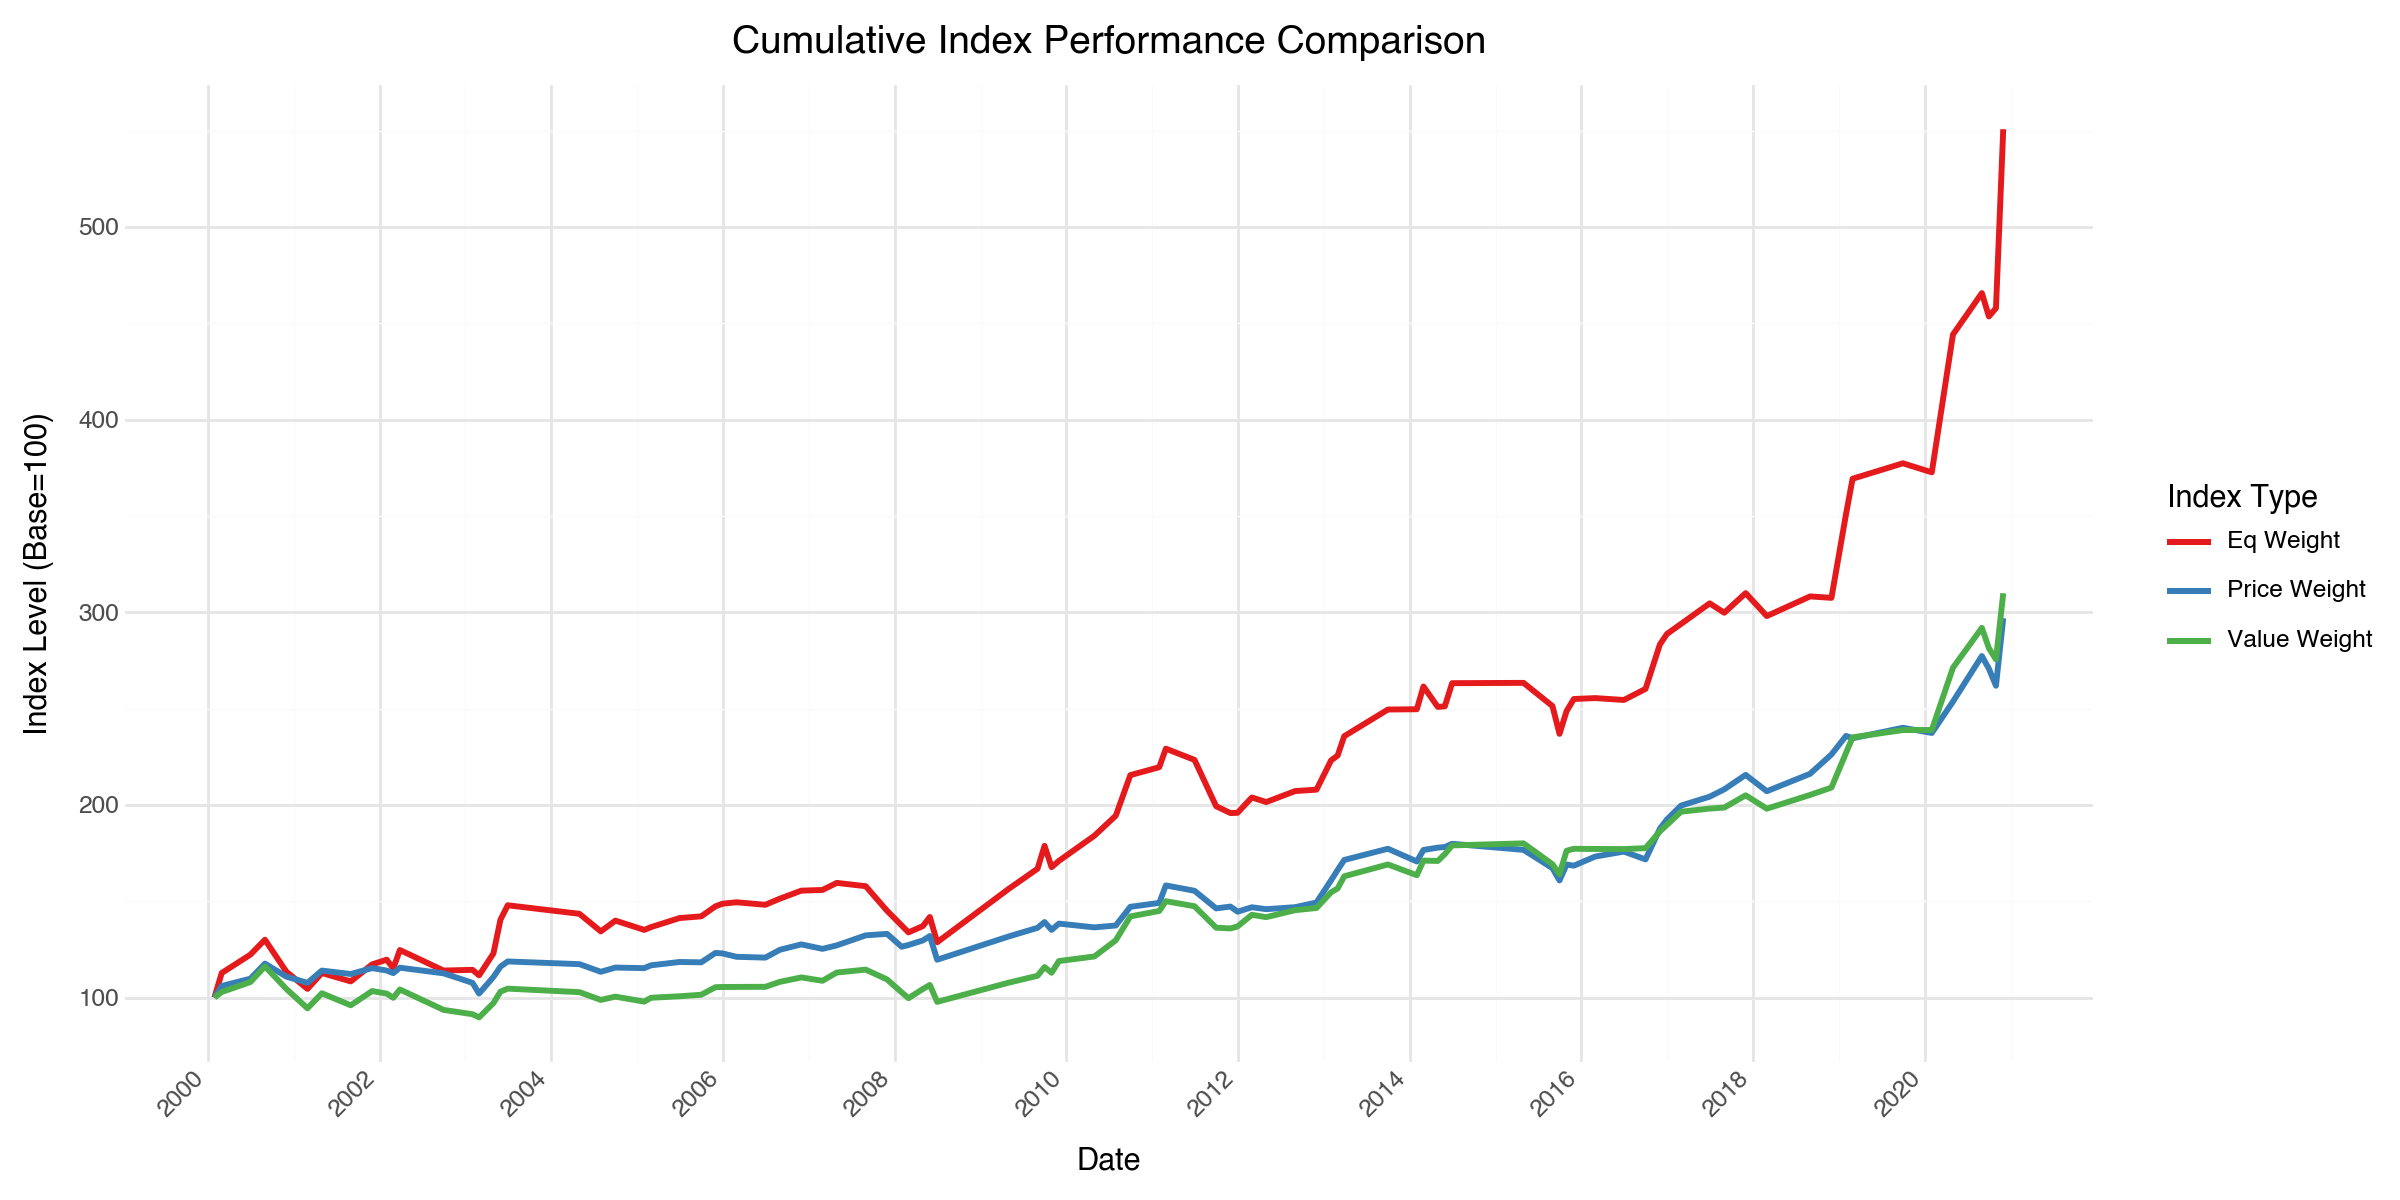

In [13]:
# Additional visualizations
if not custom_indexes.empty:
    # Calculate returns for additional plots
    returns_data = custom_indexes.copy()
    for col in ['price_weight', 'value_weight', 'eq_weight']:
        if col in returns_data.columns:
            returns_data[f'{col}_return'] = returns_data[col].pct_change()
    
    # 1. Returns distribution
    returns_plot_data = returns_data.melt(
        id_vars=['date'],
        value_vars=['price_weight_return', 'value_weight_return', 'eq_weight_return'],
        var_name='index_type',
        value_name='return'
    )
    returns_plot_data['index_type'] = returns_plot_data['index_type'].str.replace('_return', '').str.replace('_', ' ').str.title()
    
    p1 = (ggplot(returns_plot_data, aes(x='return', fill='index_type')) +
          geom_histogram(bins=30, alpha=0.7, position='identity') +
          facet_wrap('~index_type', scales='free') +
          labs(
              title='Monthly Return Distributions',
              x='Monthly Return',
              y='Frequency'
          ) +
          theme_minimal() +
          theme(figure_size=(12, 6)) +
          scale_fill_brewer(type='qual', palette='Set1')
    )
    
    print("Returns Distribution:")
    print(p1)
    
    # 2. Cumulative returns comparison
    p2 = (ggplot(plot_data, aes(x='date', y='index_level', color='index_type')) +
          geom_line(size=1.2) +
          labs(
              title='Cumulative Index Performance Comparison',
              x='Date',
              y='Index Level (Base=100)',
              color='Index Type'
          ) +
          theme_minimal() +
          theme(
              figure_size=(12, 6),
              plot_title=element_text(size=14, weight='bold'),
              axis_text_x=element_text(angle=45, hjust=1)
          ) +
          scale_color_brewer(type='qual', palette='Set1') +
          scale_x_date(date_labels='%Y', date_breaks='2 years')
    )
    
    print("\nCumulative Performance:")
    p2.show()


In [9]:
# Display summary statistics
if custom_indexes.empty:
    print("Cannot calculate performance statistics - no data available")
else:
    print("Index Performance Summary:")
    print("=" * 50)

    for col in ['price_weight', 'value_weight', 'eq_weight']:
        if col in custom_indexes.columns and not custom_indexes[col].empty:
            returns = custom_indexes[col].pct_change().dropna()
            
            print(f"\n{col.replace('_', ' ').title()}:")
            print(f"  Final Level: {custom_indexes[col].iloc[-1]:.2f}")
            print(f"  Total Return: {(custom_indexes[col].iloc[-1] / 100 - 1) * 100:.2f}%")
            print(f"  Annualized Return: {((1 + returns.mean())**12 - 1) * 100:.2f}%")
            print(f"  Annualized Volatility: {returns.std() * np.sqrt(12) * 100:.2f}%")
            print(f"  Sharpe Ratio: {((1 + returns.mean())**12 - 1) / (returns.std() * np.sqrt(12)):.3f}")
            print(f"  Max Drawdown: {((custom_indexes[col] / custom_indexes[col].cummax()) - 1).min() * 100:.2f}%")


Index Performance Summary:

Price Weight:
  Final Level: 296.88
  Total Return: 196.88%
  Annualized Return: 16.29%
  Annualized Volatility: 13.67%
  Sharpe Ratio: 1.192
  Max Drawdown: -13.22%

Value Weight:
  Final Level: 309.83
  Total Return: 209.83%
  Annualized Return: 17.37%
  Annualized Volatility: 16.13%
  Sharpe Ratio: 1.076
  Max Drawdown: -22.79%

Eq Weight:
  Final Level: 550.66
  Total Return: 450.66%
  Annualized Return: 27.65%
  Annualized Volatility: 21.52%
  Sharpe Ratio: 1.285
  Max Drawdown: -19.63%


In [10]:
# Close database connection
db.close()
print("\nWRDS connection closed")



WRDS connection closed


In [11]:
# Alternative: Simple text-based summary if plotting fails
if not custom_indexes.empty:
    print("\n" + "="*60)
    print("CUSTOM INDEX PERFORMANCE SUMMARY")
    print("="*60)
    
    for col in ['price_weight', 'value_weight', 'eq_weight']:
        if col in custom_indexes.columns:
            print(f"\n{col.replace('_', ' ').upper()}:")
            print(f"  Start Level: {custom_indexes[col].iloc[0]:.2f}")
            print(f"  End Level: {custom_indexes[col].iloc[-1]:.2f}")
            print(f"  Total Return: {(custom_indexes[col].iloc[-1] / custom_indexes[col].iloc[0] - 1) * 100:.2f}%")
            
            # Show first few and last few values
            print(f"  First 5 values: {custom_indexes[col].head().round(2).tolist()}")
            print(f"  Last 5 values: {custom_indexes[col].tail().round(2).tolist()}")
    
    print(f"\nData Summary:")
    print(f"  Total observations: {len(custom_indexes)}")
    print(f"  Date range: {custom_indexes['date'].min()} to {custom_indexes['date'].max()}")
    print(f"  Columns: {list(custom_indexes.columns)}")



CUSTOM INDEX PERFORMANCE SUMMARY

PRICE WEIGHT:
  Start Level: 100.00
  End Level: 296.88
  Total Return: 196.88%
  First 5 values: [100.0, 106.0, 109.8, 117.62, 110.85]
  Last 5 values: [253.61, 277.25, 270.63, 261.83, 296.88]

VALUE WEIGHT:
  Start Level: 100.00
  End Level: 309.83
  Total Return: 209.83%
  First 5 values: [100.0, 102.88, 108.04, 116.17, 104.46]
  Last 5 values: [271.18, 291.87, 281.31, 275.49, 309.83]

EQ WEIGHT:
  Start Level: 100.00
  End Level: 550.66
  Total Return: 450.66%
  First 5 values: [100.0, 112.74, 122.27, 130.01, 113.42]
  Last 5 values: [444.11, 465.62, 453.49, 457.83, 550.66]

Data Summary:
  Total observations: 93
  Date range: 2000-01-29 00:00:00 to 2020-11-30 00:00:00
  Columns: ['date', 'price_weight_return', 'value_weight_return', 'eq_weight_return', 'price_weight', 'value_weight', 'eq_weight']
